### Parte 2

Realizar un acercamiento a una base de datos de señales ECG, disponible en:
https://figshare.com/collections/ChapmanECG/4560497. Identificar sus principales características y
realizando un análisis estadístico que permita determinar si existen diferencias significativas entre los grupos
de sujetos con diferentes tipos de arritmias (utilizar los datos disponibles en los archivos filtrados
ECGDataDenoised.zip).

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np


#### **Tipos de ritmos de los latidos cardiacos presentes en los datos**
Estas arritmias se encuentran en el canal 2 de "Diagnostics" la columna se llama "Rhythm"

- **SB - (Sinus Bradycardia):** ritmo cardíaco en el que el corazón late a menos de 60 latidos por minuto (Tipo de arritmia en personas con excelente condicion fisica). Sí, puede clasificarse como una alteración del ritmo, aunque no siempre se considera una arritmia patológica.

- **SR — Ritmo sinusal:** Es el ritmo cardíaco normal generado por el nodo sinusal, con activación ordenada de las aurículas y los ventrículos. No es una arritmia.

- **AFIB - Atrial Fibrillation:** La fibrilación auricular es la alteración del ritmo cardíaco o arritmia más común, la cual hace que las cavidades superiores del corazón latan de forma rápida, caótica e irregular. Sí, es una arritmia.

- **ST — Taquicardia sinusal:** Es un ritmo originado en el nodo sinusal con una frecuencia cardíaca superior a 100 latidos por minuto, generalmente como respuesta a ejercicio, estrés, fiebre u otras condiciones. No necesariamente es una arritmia; puede ser una respuesta fisiológica normal.

- **AF	Atrial Flutter:** es un tipo de arritmia  en el cual las cavidades superiores del corazón (las aurículas) laten de manera muy rápida y organizada, por lo general entre 240 y 340 latidos por minuto. Sí, es una arritmia.

- **SI — Irregularidad sinusal:** Es una variación del intervalo entre los latidos que mantiene su origen en el nodo sinusal; puede presentarse normalmente, por ejemplo, relacionada con la respiración. Generalmente no se considera una arritmia patológica.

- **SVT — Taquicardia supraventricular:** Es un ritmo cardíaco acelerado cuyo origen se encuentra por encima de los ventrículos, en las aurículas o en la región auriculoventricular. Sí, es una arritmia.

- **AT — Taquicardia auricular:** Es una taquicardia cuyo origen se encuentra en un foco anormal dentro de las aurículas, diferente al nodo sinusal. Sí, es una arritmia.

- **AVNRT — Taquicardia por reentrada intranodal auriculoventricular:** Es una taquicardia causada por un circuito eléctrico de reentrada dentro o cerca del nodo auriculoventricular, que provoca latidos rápidos. Sí, es una arritmia.

- **AVRT — Taquicardia por reentrada auriculoventricular:** Es una taquicardia producida por un circuito eléctrico que utiliza una vía accesoria entre las aurículas y los ventrículos. Sí, es una arritmia.

- **SAAWR — Ritmo auricular errante (marcapasos auricular migratorio):** Es un ritmo en el que el sitio que genera los impulsos eléctricos cambia entre diferentes zonas de las aurículas, produciendo variaciones en la morfología de la onda P. Generalmente no se considera una arritmia peligrosa y puede ser una variante benigna del ritmo cardíaco.


#### **Obtención de datos**

In [3]:
#Extrapolado a muchos pacientes 

# ------------------------------------------------------------
# 1. Ubicación de los archivos
# ------------------------------------------------------------

# Carpeta donde se encuentran los archivos ECG
SIGNALS_DIR = Path(
    r"C:\Documentos\Octavo semestre 2026-2\Bioseñales\laboratorio\ECGDataDenoised\ECGDataDenoised"
)


# Excel donde se encuentra la metdata de cada paciente (Archivo de diagnóstico)
DIAGNOSTICS_PATH = Path(r"C:\Documentos\Octavo semestre 2026-2\Bioseñales\laboratorio\ECGDataDenoised\Diagnostics.xlsx")




# ------------------------------------------------------------
# 2. Parámetros de los registros ECG
# ------------------------------------------------------------

# Frecuencia de muestreo: 500 muestras por segundo
FS = 500  # Hz

# 12 derivaciones del ECG
LEADS = [
    "I", "II", "III", "aVR", "aVL", "aVF",
    "V1", "V2", "V3", "V4", "V5", "V6"
]


# ------------------------------------------------------------
# 3. Leer Diagnostics.xlsx
# ------------------------------------------------------------

diagnostics = pd.read_excel(DIAGNOSTICS_PATH)


# ------------------------------------------------------------
# 4. Identificar la segunda columna
# ------------------------------------------------------------

# La segunda columna contiene la condición/diagnóstico
diagnosis_column = diagnostics.columns[1]

print("Columna utilizada para identificar el diagnóstico:")
print(diagnosis_column)


# ------------------------------------------------------------

# ARRITMIA SB
# 5. Seleccionar únicamente los registros con condición SB
# ------------------------------------------------------------

sb_diagnostics = diagnostics[
    diagnostics[diagnosis_column]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("SB")
].copy()


# ------------------------------------------------------------
# 6. Obtener los nombres de los archivos de los pacientes
# ------------------------------------------------------------

FILENAME_SB = sb_diagnostics["FileName"].astype(str).tolist()


# ------------------------------------------------------------
# 7. Mostrar los resultados
# ------------------------------------------------------------

print(f"\nNúmero de pacientes/registros con SB: {len(FILENAME_SB)}")

#print("\nNombres de los archivos:")
for i, filename in enumerate(FILENAME_SB, start=1):
    print(f"{i}. {filename}")

Columna utilizada para identificar el diagnóstico:
Rhythm

Número de pacientes/registros con SB: 3889
1. MUSE_20180112_073319_29000
2. MUSE_20180113_121940_44000
3. MUSE_20180112_120347_79000
4. MUSE_20180114_075128_92000
5. MUSE_20180118_174026_42000
6. MUSE_20180115_125443_25000
7. MUSE_20180113_134825_04000
8. MUSE_20180114_070718_20000
9. MUSE_20180115_133559_70000
10. MUSE_20180113_071734_35000
11. MUSE_20180114_121218_64000
12. MUSE_20180113_075301_94000
13. MUSE_20180114_122918_82000
14. MUSE_20180118_135246_80000
15. MUSE_20180118_132124_94000
16. MUSE_20180118_134426_93000
17. MUSE_20180116_130527_79000
18. MUSE_20180113_131417_18000
19. MUSE_20180116_124959_22000
20. MUSE_20180116_132201_77000
21. MUSE_20180115_124515_42000
22. MUSE_20180114_072951_09000
23. MUSE_20180113_175348_27000
24. MUSE_20180119_171326_67000
25. MUSE_20180115_121230_14000
26. MUSE_20180113_130248_31000
27. MUSE_20180116_130424_37000
28. MUSE_20180114_072023_07000
29. MUSE_20180116_134125_04000
30. MUSE

In [4]:
#ARRITMIA ST

ST_diagnostics = diagnostics[
    diagnostics[diagnosis_column]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("ST")
].copy()


# ------------------------------------------------------------
# 6. Obtener los nombres de los archivos de los pacientes
# ------------------------------------------------------------

FILENAME_ST = ST_diagnostics["FileName"].astype(str).tolist()


# ------------------------------------------------------------
# 7. Mostrar los resultados
# ------------------------------------------------------------

print(f"\nNúmero de pacientes/registros con ST: {len(FILENAME_ST)}")

#print("\nNombres de los archivos:")
for i, filename in enumerate(FILENAME_ST, start=1):
    print(f"{i}. {filename}")


Número de pacientes/registros con ST: 1568
1. MUSE_20180113_135023_96000
2. MUSE_20180116_170254_89000
3. MUSE_20180114_121405_34000
4. MUSE_20180119_173922_99000
5. MUSE_20180113_131104_16000
6. MUSE_20180115_122814_91000
7. MUSE_20180114_074225_84000
8. MUSE_20180116_171134_36000
9. MUSE_20180115_124947_77000
10. MUSE_20180112_075642_49000
11. MUSE_20180115_122421_01000
12. MUSE_20180118_133137_91000
13. MUSE_20180120_123332_54000
14. MUSE_20180119_180323_39000
15. MUSE_20180113_123655_66000
16. MUSE_20180113_125917_68000
17. MUSE_20180120_121328_78000
18. MUSE_20180112_135455_73000
19. MUSE_20180115_120047_83000
20. MUSE_20180112_140253_84000
21. MUSE_20180113_132903_75000
22. MUSE_20180119_171537_62000
23. MUSE_20180119_170706_66000
24. MUSE_20180112_135515_59000
25. MUSE_20180112_141122_73000
26. MUSE_20180115_134257_52000
27. MUSE_20180114_170335_78000
28. MUSE_20180118_175846_80000
29. MUSE_20180113_183129_25000
30. MUSE_20180111_165705_74000
31. MUSE_20180113_120859_09000
32. 

#### **Metadata de los pacientes con sus respectivas arritmias**

In [5]:
#Extrapolado a todos los pacientes con la condicion de SB

# ============================================================
# PARTE 2: ORGANIZAR LOS METADATOS DE TODOS LOS PACIENTES SB
# ============================================================

# ------------------------------------------------------------
# 1. Crear una tabla con todos los metadatos de los pacientes SB
# ------------------------------------------------------------

subject_meta = diagnostics[
    diagnostics["FileName"].astype(str).isin(FILENAME_SB)
].copy()


# ------------------------------------------------------------
# 2. Reiniciar los índices
# ------------------------------------------------------------

subject_meta = subject_meta.reset_index(drop=True)


# ------------------------------------------------------------
# 3. Mostrar la tabla completa
# ------------------------------------------------------------

subject_meta

,FileName,Rhythm,Beat,PatientAge,Gender,VentricularRate,AtrialRate,QRSDuration,QTInterval,QTCorrected,RAxis,TAxis,QRSCount,QOnset,QOffset,TOffset
0,MUSE_20180112_073319_29000,SB,TWC,59,FEMALE,52,52,92,432,401,76,42,8,215,261,431
1,MUSE_20180113_121940_44000,SB,NONE,66,MALE,53,53,96,456,427,34,3,9,219,267,447
2,MUSE_20180112_120347_79000,SB,NONE,46,FEMALE,57,57,70,404,393,38,24,9,225,260,427
3,MUSE_20180114_075128_92000,SB,NONE,45,MALE,59,59,84,390,386,78,68,10,218,260,413
4,MUSE_20180118_174026_42000,SB,NONE,47,FEMALE,58,58,80,420,412,80,48,10,212,252,422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3884,MUSE_20180114_070348_17000,SB,RBBB,62,MALE,55,55,124,440,420,48,28,9,221,283,441
3885,MUSE_20180114_134724_10000,SB,LVHV,56,FEMALE,56,56,88,444,428,49,62,9,219,263,441
3886,MUSE_20180113_122544_20000,SB,NONE,38,FEMALE,56,56,88,434,418,69,54,10,218,262,435
3887,MUSE_20180114_074720_85000,SB,NONE,55,FEMALE,57,57,94,414,402,-4,1,10,212,259,419


#### **Señales ECG**

Para SB

In [6]:

# ============================================================
# 1. DICCIONARIO PARA ALMACENAR TODOS LOS ECG
# ============================================================
# Cada archivo tendrá:
# ECG_SB["nombre_archivo"] -> información de ese paciente

ECG_SB = {}


# ============================================================
# 2. RECORRER TODOS LOS PACIENTES SB
# ============================================================

for i, filename in enumerate(FILENAME_SB, start=1):

    # --------------------------------------------------------
    # Asegurar que filename sea texto
    # --------------------------------------------------------

    filename = str(filename).strip()


    # --------------------------------------------------------
    # Agregar .csv si no está presente
    # --------------------------------------------------------

    if not filename.lower().endswith(".csv"):
        filename += ".csv"


    # --------------------------------------------------------
    # Crear la ruta del archivo
    # --------------------------------------------------------

    signal_path = SIGNALS_DIR / filename


    # --------------------------------------------------------
    # Verificar que exista
    # --------------------------------------------------------

    if not signal_path.is_file():

        print(f"⚠️ No encontrado: {filename}")

        continue


    # --------------------------------------------------------
    # Leer el ECG
    # --------------------------------------------------------

    ecg_signal = pd.read_csv(
        signal_path,
        header=None,
        names=LEADS
    )


    # --------------------------------------------------------
    # Número de muestras
    # --------------------------------------------------------

    n_samples = len(ecg_signal)


    # --------------------------------------------------------
    # Crear vector de tiempo
    # --------------------------------------------------------

    t = np.arange(n_samples) / FS


    # --------------------------------------------------------
    # Guardar TODOS los datos
    # --------------------------------------------------------

    ECG_SB[filename] = {
        "Signal": ecg_signal,
        "Time": t,
        "n_samples": n_samples
    }


    # --------------------------------------------------------
    # Mostrar progreso cada 100 pacientes
    # --------------------------------------------------------

    if i % 100 == 0:
        print(f"Procesados: {i}/{len(FILENAME_SB)}")


# ============================================================
# 3. RESUMEN
# ============================================================

print("\n==========================================")
print("PROCESAMIENTO FINALIZADO")
print("==========================================")

print(f"Archivos solicitados : {len(FILENAME_SB)}")
print(f"ECG cargados         : {len(ECG_SB)}")


# ============================================================
# 4. VERIFICAR EL PRIMER ECG
# ============================================================

if ECG_SB:

    primer_nombre = next(iter(ECG_SB))

    print("\nPrimer ECG:")
    print(primer_nombre)

    print("\nPrimeras muestras:")
    display(ECG_SB[primer_nombre]["Signal"].head())

Procesados: 100/3889
Procesados: 200/3889
Procesados: 300/3889
Procesados: 400/3889
Procesados: 500/3889
Procesados: 600/3889
Procesados: 700/3889
Procesados: 800/3889
Procesados: 900/3889
Procesados: 1000/3889
Procesados: 1100/3889
Procesados: 1200/3889
Procesados: 1300/3889
Procesados: 1400/3889
Procesados: 1500/3889
Procesados: 1600/3889
Procesados: 1700/3889
Procesados: 1800/3889
Procesados: 1900/3889
Procesados: 2000/3889
Procesados: 2100/3889
Procesados: 2200/3889
Procesados: 2300/3889
Procesados: 2400/3889
Procesados: 2500/3889
Procesados: 2600/3889
Procesados: 2700/3889
Procesados: 2800/3889
Procesados: 2900/3889
Procesados: 3000/3889
Procesados: 3100/3889
Procesados: 3200/3889
Procesados: 3300/3889
Procesados: 3400/3889
Procesados: 3500/3889
Procesados: 3600/3889
Procesados: 3700/3889
Procesados: 3800/3889

PROCESAMIENTO FINALIZADO
Archivos solicitados : 3889
ECG cargados         : 3889

Primer ECG:
MUSE_20180112_073319_29000.csv

Primeras muestras:


,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
0,-16.252,27.3670,56.396,-4.82140,-27.812,37.755,23.591,-137.44,-69.272,-123.78,-35.297,-17.9260
1,-14.335,21.5670,48.769,-2.33830,-23.743,30.828,25.655,-136.60,-65.699,-124.20,-33.326,-15.5350
2,-13.860,16.2690,43.085,0.47014,-21.295,25.141,27.769,-134.81,-62.197,-123.90,-31.043,-12.6400
3,-16.099,11.3130,40.455,4.21340,-21.582,21.179,29.601,-131.53,-59.106,-122.90,-28.795,-9.4608
4,-21.742,5.8746,40.746,9.63630,-24.816,18.448,30.454,-126.86,-57.057,-122.13,-27.611,-7.0034


#### **Visualización de la señal**

Para SB

<Figure size 1400x800 with 0 Axes>

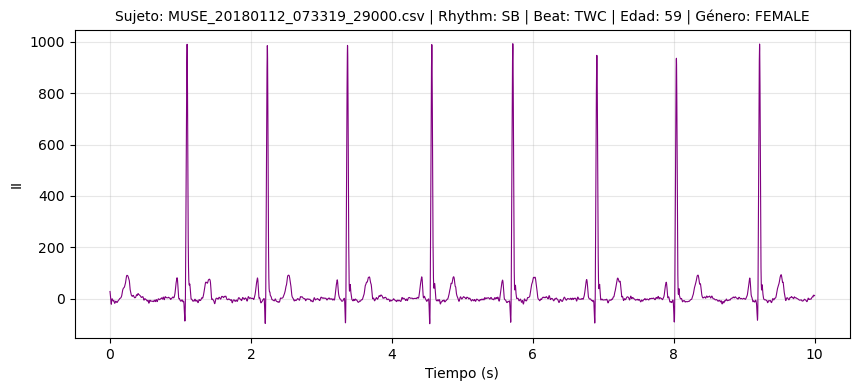

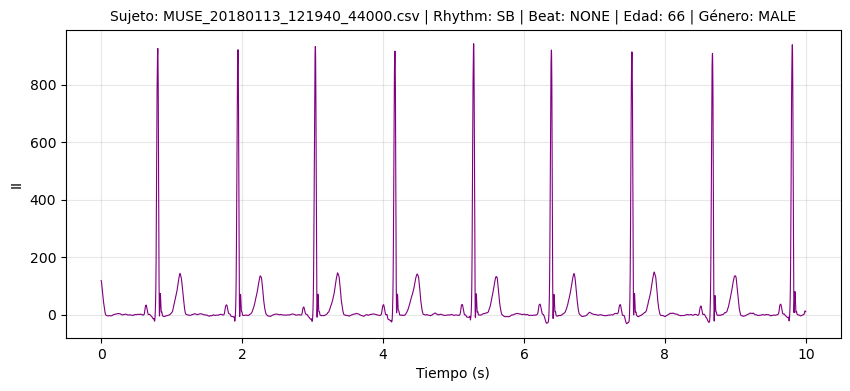

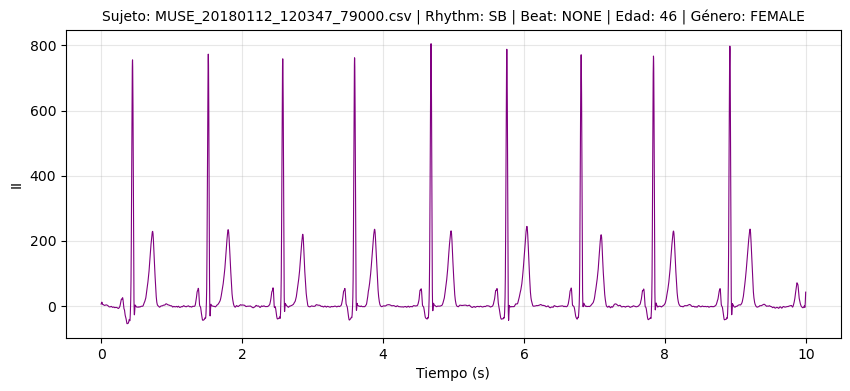

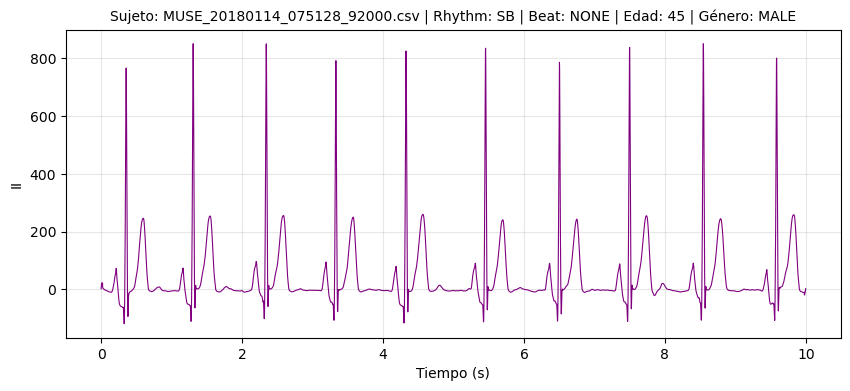

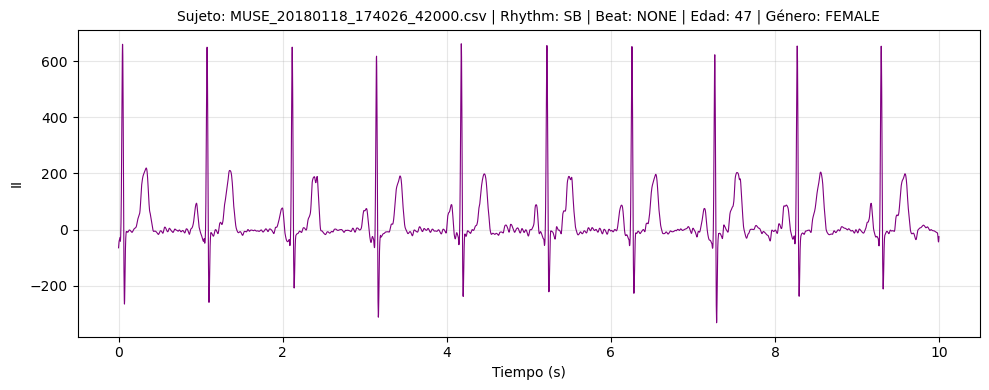

In [20]:
# ============================================================
# GRAFICAR DOS SUJETOS SB
# ============================================================

# Seleccionar dos sujetos de los ECG que ya fueron cargados
subject_files = list(ECG_SB.keys())[:5]


# Crear figura
plt.figure(figsize=(14, 8))


# ============================================================
# RECORRER LOS DOS SUJETOS
# ============================================================

for i, fname in enumerate(subject_files, start=1):

    # --------------------------------------------------------
    # Obtener los metadatos del paciente
    # --------------------------------------------------------

    meta = diagnostics[
        diagnostics["FileName"] == Path(fname).stem
    ].reset_index(drop=True)


    # --------------------------------------------------------
    # Obtener la señal que ya está almacenada en ECG_SB
    # --------------------------------------------------------

    sig = ECG_SB[fname]["Signal"]

    t_sub = ECG_SB[fname]["Time"]


    # --------------------------------------------------------
    # Obtener los datos de los metadatos
    # --------------------------------------------------------

    rhythm = meta.loc[0, "Rhythm"]

    beat = meta.loc[0, "Beat"]

    age = meta.loc[0, "PatientAge"]

    gender = meta.loc[0, "Gender"]


    # ========================================================
    # GRAFICAR
    # ========================================================
    plt.figure(figsize=(10, 4))
    plt.plot(
            t_sub,
            sig["II"],
            linewidth=0.8, color = "purple"
        )
    
    plt.ylabel("II")

    plt.xlabel("Tiempo (s)")

    plt.grid(True, alpha=0.3)

    plt.title(
        f"Sujeto: {fname} | "
        f"Rhythm: {rhythm} | "
        f"Beat: {beat} | "
        f"Edad: {age} | "
        f"Género: {gender}",
        fontsize=10
    )

plt.tight_layout()

plt.show()

#### **Box plot**
Concentracion de arritmias con base a al edad 


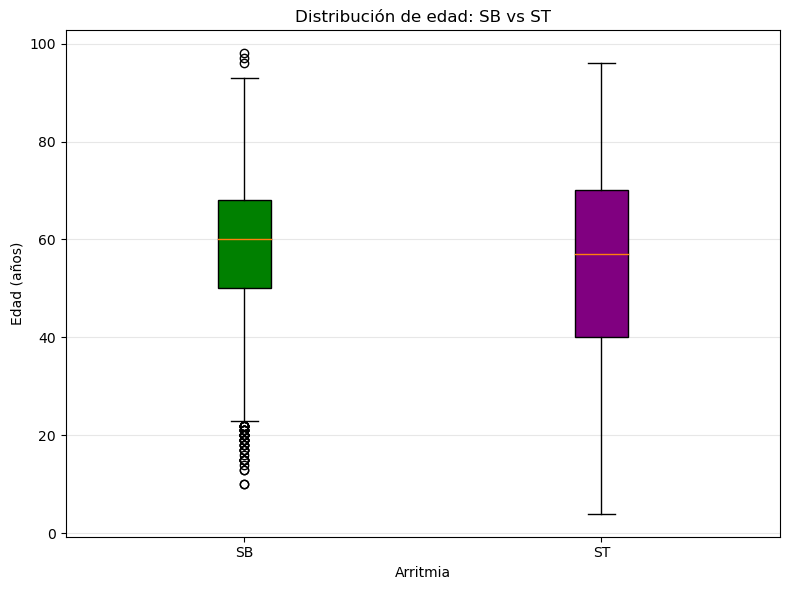

Pacientes SB: 3889
Pacientes ST: 1568


In [ ]:
# ============================================================
# 1. LISTAS PARA GUARDAR LAS EDADES
# ============================================================

edad_SB = []
edad_ST = []


# ============================================================
# 2. OBTENER EDADES DE LOS PACIENTES SB
# ============================================================

for filename in FILENAME_SB:

    nombre = Path(str(filename)).stem

    meta = diagnostics[
        diagnostics["FileName"] == nombre
    ]

    if not meta.empty:
        edad = meta.iloc[0]["PatientAge"]

        if pd.notna(edad):
            edad_SB.append(edad)


# ============================================================
# 3. OBTENER EDADES DE LOS PACIENTES ST
# ============================================================

for filename in FILENAME_ST:

    nombre = Path(str(filename)).stem

    meta = diagnostics[
        diagnostics["FileName"] == nombre
    ]

    if not meta.empty:
        edad = meta.iloc[0]["PatientAge"]

        if pd.notna(edad):
            edad_ST.append(edad)


# ============================================================
# 4. CREAR EL BOXPLOT
# ============================================================

plt.figure(figsize=(8, 6))

box = plt.boxplot(
    [edad_SB, edad_ST],
    labels=["SB", "ST"],
    patch_artist=True
)

box["boxes"][0].set_facecolor("green")   # SB
box["boxes"][1].set_facecolor("purple")     # ST

plt.xlabel("Arritmia")
plt.ylabel("Edad (años)")

plt.title("Distribución de edad: SB vs ST")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 5. MOSTRAR CUÁNTOS PACIENTES HAY EN CADA GRUPO
# ============================================================

print("Pacientes SB:", len(edad_SB))
print("Pacientes ST:", len(edad_ST))